In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')
# фиксируем для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [42]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("s3programmer/disease-diagnosis-dataset")

dataset_path = Path(path)
csv_file = dataset_path / "disease_diagnosis.csv"
df = pd.read_csv(csv_file)

print(f"Размер датасета: {df.shape}")

Using Colab cache for faster access to the 'disease-diagnosis-dataset' dataset.
Размер датасета: (2000, 13)


In [43]:
# целевые переменные
target_columns = ['Diagnosis', 'Severity', 'Treatment_Plan']

symptoms_1 = set(df['Symptom_1'].unique())
symptoms_2 = set(df['Symptom_2'].unique())
symptoms_3 = set(df['Symptom_3'].unique())

print(f"Symptom_1: {len(symptoms_1)} уникальных симптомов")
print(f"Symptom_2: {len(symptoms_2)} уникальных симптомов")
print(f"Symptom_3: {len(symptoms_3)} уникальных симптомов")

all_symptoms = symptoms_1.union(symptoms_2).union(symptoms_3)
print(f"Всего уникальных симптомов: {len(all_symptoms)}")
print(f"Все симптомы: {sorted(all_symptoms)}")

Symptom_1: 8 уникальных симптомов
Symptom_2: 8 уникальных симптомов
Symptom_3: 8 уникальных симптомов
Всего уникальных симптомов: 8
Все симптомы: ['Body ache', 'Cough', 'Fatigue', 'Fever', 'Headache', 'Runny nose', 'Shortness of breath', 'Sore throat']


In [44]:
# в трёх столбцах симптомов синонимичные записи которые могут быть в разном порядке. переводим их в бинарные есть\нет
def create_symptom_features(df):
    df_processed = df.copy()

    for symptom in all_symptoms:
        symptom_col_name = f'has_{symptom.replace(" ", "_").lower()}'
        df_processed[symptom_col_name] = (
            (df['Symptom_1'] == symptom) |
            (df['Symptom_2'] == symptom) |
            (df['Symptom_3'] == symptom)
        ).astype(int)

    df_processed = df_processed.drop(['Symptom_1', 'Symptom_2', 'Symptom_3'], axis=1)

    return df_processed

df_processed = create_symptom_features(df)

In [45]:
symptom_columns = [col for col in df_processed.columns if col.startswith('has_')]
print(f"Создано {len(symptom_columns)} бинарных признаков симптомов")

Создано 8 бинарных признаков симптомов


In [46]:
X = df_processed.drop(target_columns + ['Patient_ID', 'Blood_Pressure_mmHg'], axis=1) # дропаем бесполезные
y = df_processed[target_columns]

print(f"Признаки: {X.shape[1]}")
print(f"Целевые : {list(y.columns)}")

Признаки: 13
Целевые : ['Diagnosis', 'Severity', 'Treatment_Plan']


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y['Diagnosis']
)

print(f"Размеры данных:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Размеры данных:
X_train: (1600, 13), X_test: (400, 13)
y_train: (1600, 3), y_test: (400, 3)


In [48]:
numerical_features = ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
categorical_features = ['Gender']

print("Структура признаков:")
print(f"Числовые: {numerical_features}")
print(f"Категориальные: {categorical_features}")
print(f"Бинарные симптомы: {len(symptom_columns)} признаков")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

Структура признаков:
Числовые: ['Age', 'Heart_Rate_bpm', 'Body_Temperature_C', 'Oxygen_Saturation_%']
Категориальные: ['Gender']
Бинарные симптомы: 8 признаков


In [49]:
# для сравнения можели делаем прогон дами угадайка по самому частому классу целевых

dummy_models = {}
dummy_scores = {}

for target in target_columns:
    print(f"{target}:")
    print("-" * 30)

    dummy_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
    ])

    dummy_pipeline.fit(X_train, y_train[target])

    y_pred_dummy = dummy_pipeline.predict(X_test)

    precision_macro = precision_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)
    recall_macro = recall_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)
    f1_macro = f1_score(y_test[target], y_pred_dummy, average='macro', zero_division=0)

    dummy_scores[target] = {
        'precision': precision_macro,
        'recall': recall_macro,
        'f1': f1_macro
    }
    dummy_models[target] = dummy_pipeline

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")

Diagnosis:
------------------------------
Macro Precision: 0.1165
Macro Recall: 0.2000
Macro F1-score: 0.1472
Severity:
------------------------------
Macro Precision: 0.2217
Macro Recall: 0.3333
Macro F1-score: 0.2663
Treatment_Plan:
------------------------------
Macro Precision: 0.2217
Macro Recall: 0.3333
Macro F1-score: 0.2663


In [50]:
mean_dummy_f1 = np.mean([score['f1'] for score in dummy_scores.values()])
mean_dummy_precision = np.mean([score['precision'] for score in dummy_scores.values()])
mean_dummy_recall = np.mean([score['recall'] for score in dummy_scores.values()])

print(f"СРЕДНИЕ МЕТРИКИ DUMMY CLASSIFIER:")
print(f"Macro Precision: {mean_dummy_precision:.4f}")
print(f"Macro Recall: {mean_dummy_recall:.4f}")
print(f"Macro F1-score: {mean_dummy_f1:.4f}")

СРЕДНИЕ МЕТРИКИ DUMMY CLASSIFIER:
Macro Precision: 0.1866
Macro Recall: 0.2889
Macro F1-score: 0.2266


In [51]:
# метрики очень не очень

In [52]:
# нормальное дерево классификации по трём целевым

dt_models = {}
dt_scores = {}

for target in target_columns:
    print(f"{target}:")
    print("-" * 30)

    dt_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    dt_pipeline.fit(X_train, y_train[target])

    y_pred_dt = dt_pipeline.predict(X_test)

    precision_macro = precision_score(y_test[target], y_pred_dt, average='macro', zero_division=0)
    recall_macro = recall_score(y_test[target], y_pred_dt, average='macro', zero_division=0)
    f1_macro = f1_score(y_test[target], y_pred_dt, average='macro', zero_division=0)

    dt_scores[target] = {
        'precision': precision_macro,
        'recall': recall_macro,
        'f1': f1_macro
    }
    dt_models[target] = dt_pipeline

    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1-score: {f1_macro:.4f}")

    improvement = f1_macro - dummy_scores[target]['f1']
    improvement_pct = (improvement / dummy_scores[target]['f1']) * 100 if dummy_scores[target]['f1'] > 0 else np.inf
    print(f"Улучшение над бейзлайном: {improvement:+.4f} ({improvement_pct:+.1f}%)")

Diagnosis:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.8528 (+579.2%)
Severity:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.7337 (+275.6%)
Treatment_Plan:
------------------------------
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Улучшение над бейзлайном: +0.7337 (+275.6%)


In [66]:
mean_dt_f1 = np.mean([score['f1'] for score in dt_scores.values()])
mean_dt_precision = np.mean([score['precision'] for score in dt_scores.values()])
mean_dt_recall = np.mean([score['recall'] for score in dt_scores.values()])

print(f" МЕТРИКИ DECISION TREE:")
print(f"Macro Precision: {mean_dt_precision:.4f}")
print(f"Macro Recall: {mean_dt_recall:.4f}")
print(f"Macro F1-score: {mean_dt_f1:.4f}")
print(f"Средний F1 бейзлайна: {mean_dummy_f1:.4f}")
print(f"Средний F1 Decision Tree: {mean_dt_f1:.4f}")
print(f"Абсолютное улучшение: {mean_dt_f1 - mean_dummy_f1:+.4f}")
print(f"Относительное улучшение F1 над бейзлайном: {((mean_dt_f1 - mean_dummy_f1) / mean_dummy_f1) * 100:+.2f}%")

 МЕТРИКИ DECISION TREE:
Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1-score: 1.0000
Средний F1 бейзлайна: 0.2266
Средний F1 Decision Tree: 1.0000
Абсолютное улучшение: +0.7734
Относительное улучшение F1 над бейзлайном: +341.33%


In [54]:
# метрики намного выше дами

Всего признаков: 13
Глубина дерева: 5
Количество листьев: 18


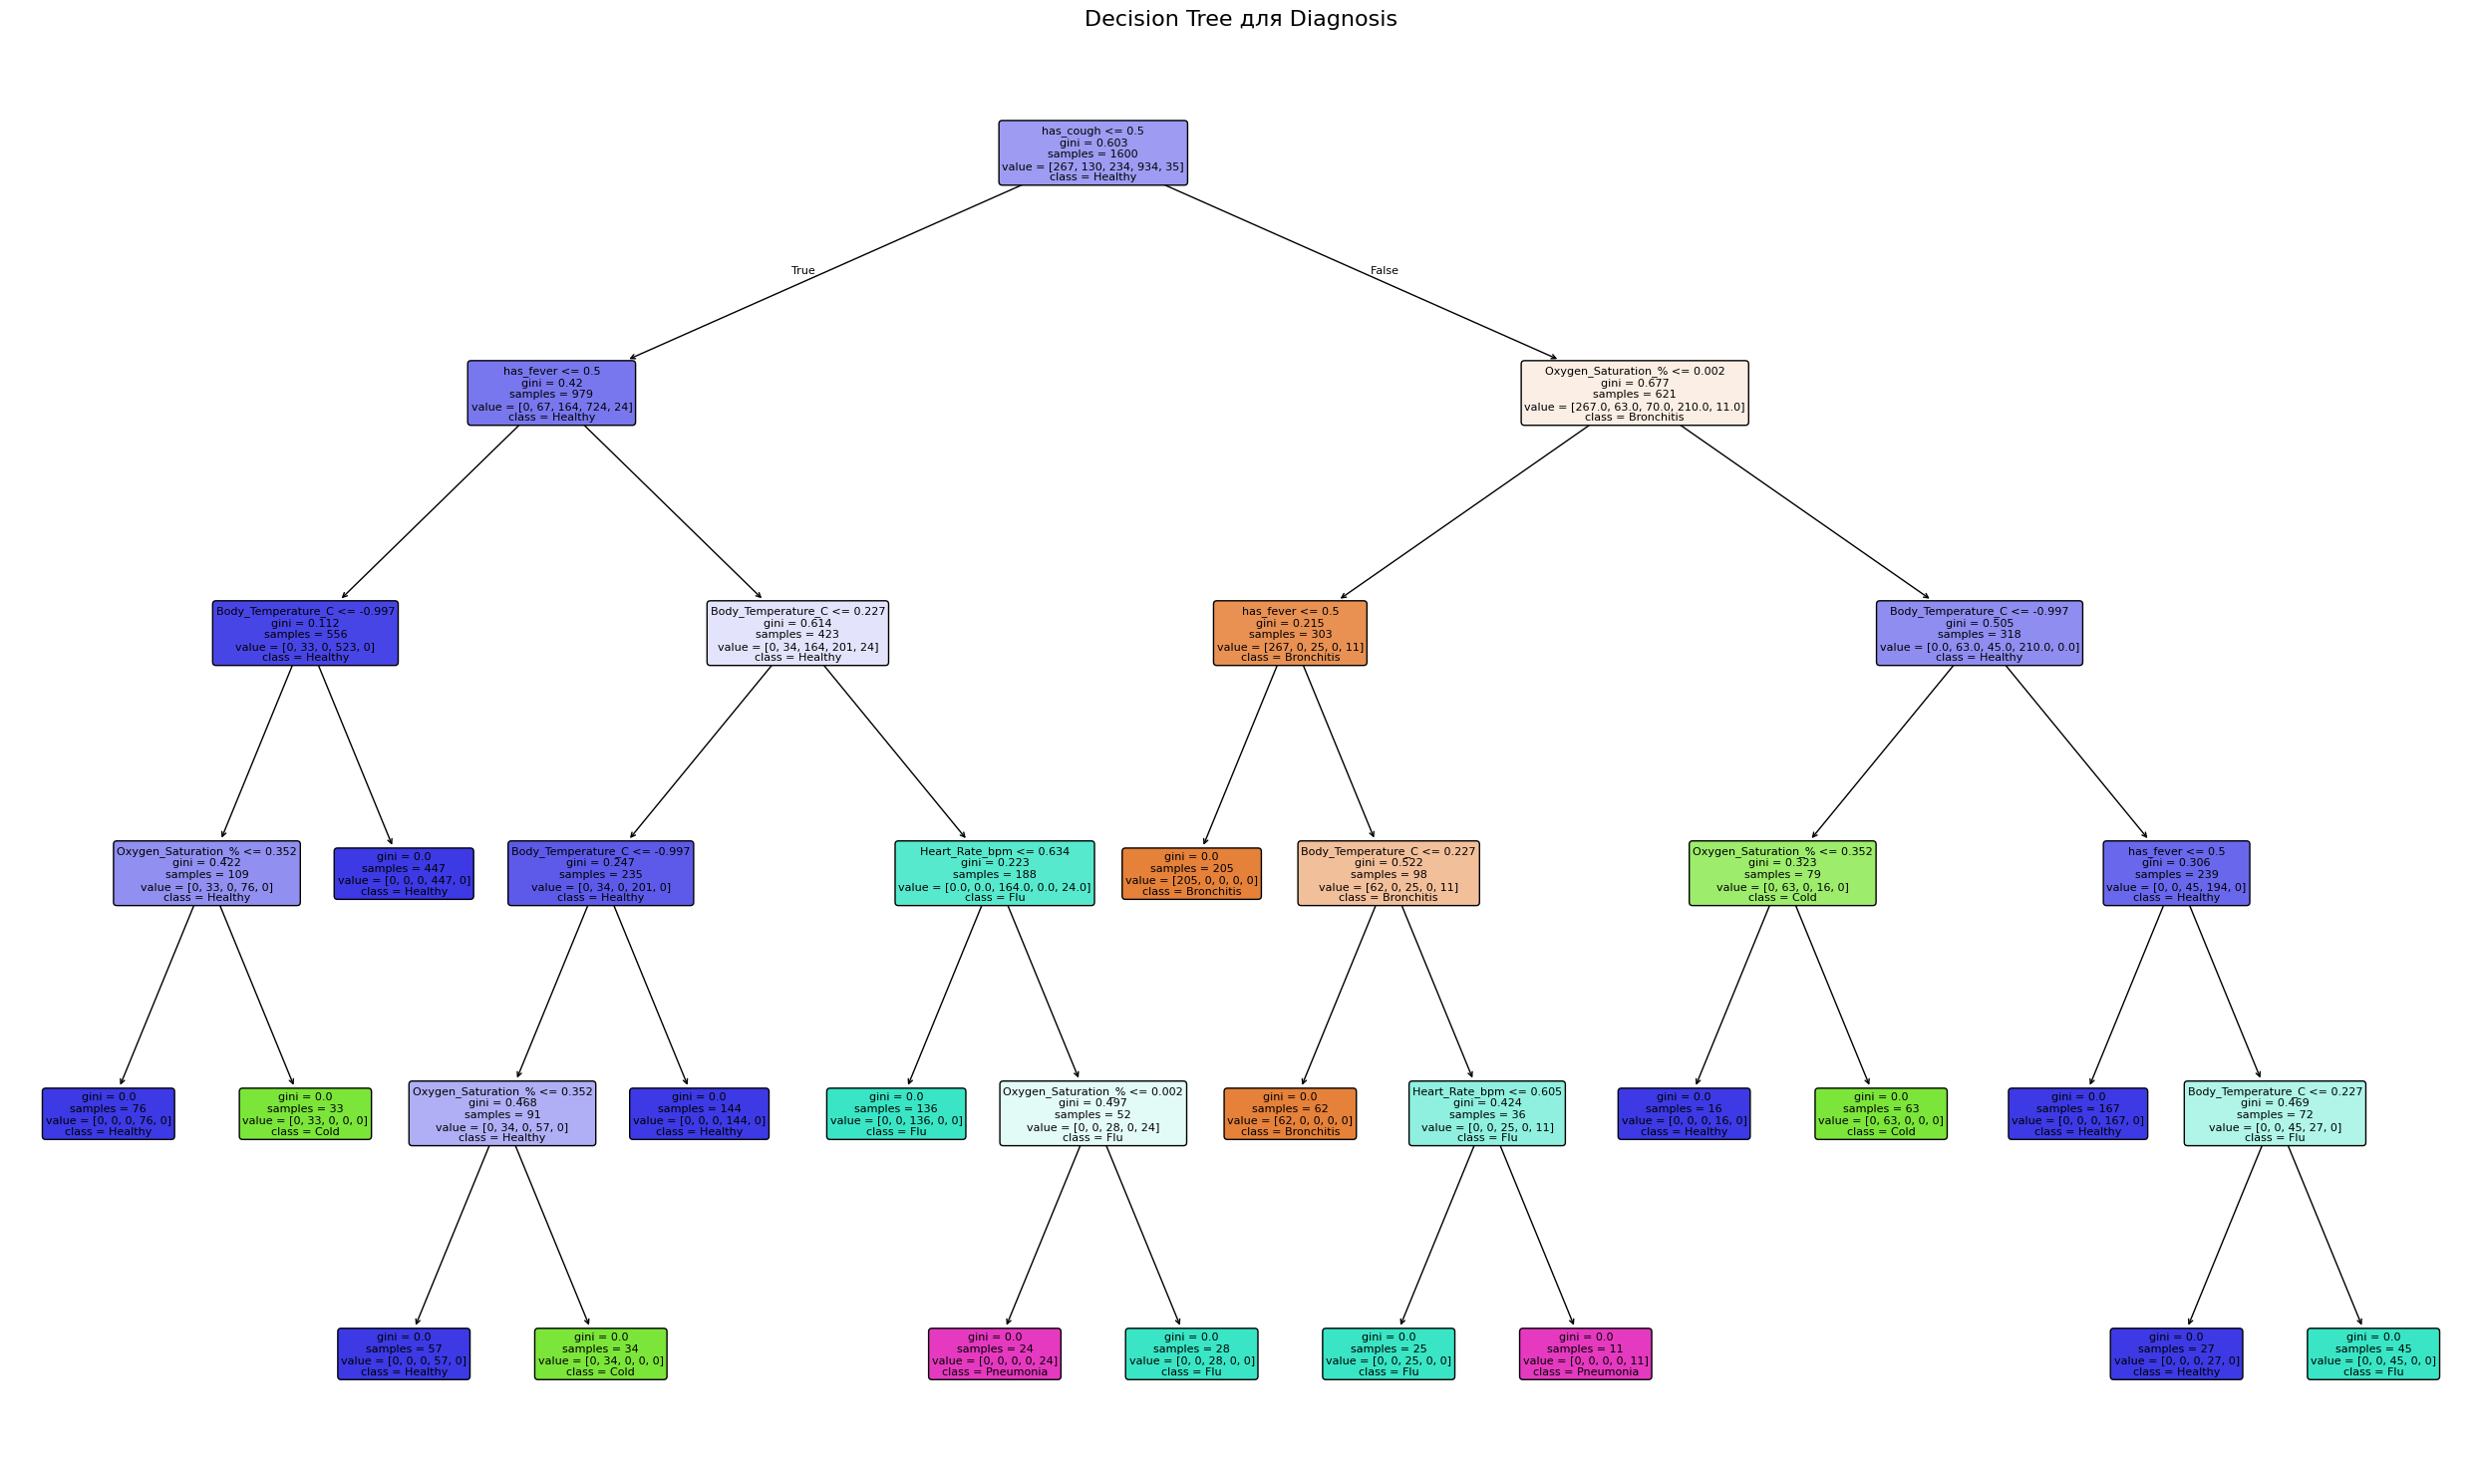

In [55]:
# рисуем деревья с решающими правилами для всех трёх целевых

dt_diagnosis = dt_models['Diagnosis']

numerical_names = numerical_features
categorical_names = list(dt_diagnosis.named_steps['preprocessor']
                       .named_transformers_['cat']
                       .get_feature_names_out(categorical_features))
all_feature_names = numerical_names + categorical_names + symptom_columns

print(f"Всего признаков: {len(all_feature_names)}")
print(f"Глубина дерева: {dt_diagnosis.named_steps['model'].get_depth()}")
print(f"Количество листьев: {dt_diagnosis.named_steps['model'].get_n_leaves()}")

plt.figure(figsize=(25, 15))
plot_tree(dt_diagnosis.named_steps['model'],
          feature_names=all_feature_names,
          class_names=list(dt_diagnosis.named_steps['model'].classes_),
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=5)
plt.title('Decision Tree для Diagnosis', fontsize=16)
plt.tight_layout()
plt.show()

 DECISION TREE - DIAGNOSIS


Всего признаков: 13
Глубина дерева: 5
Количество листьев: 18


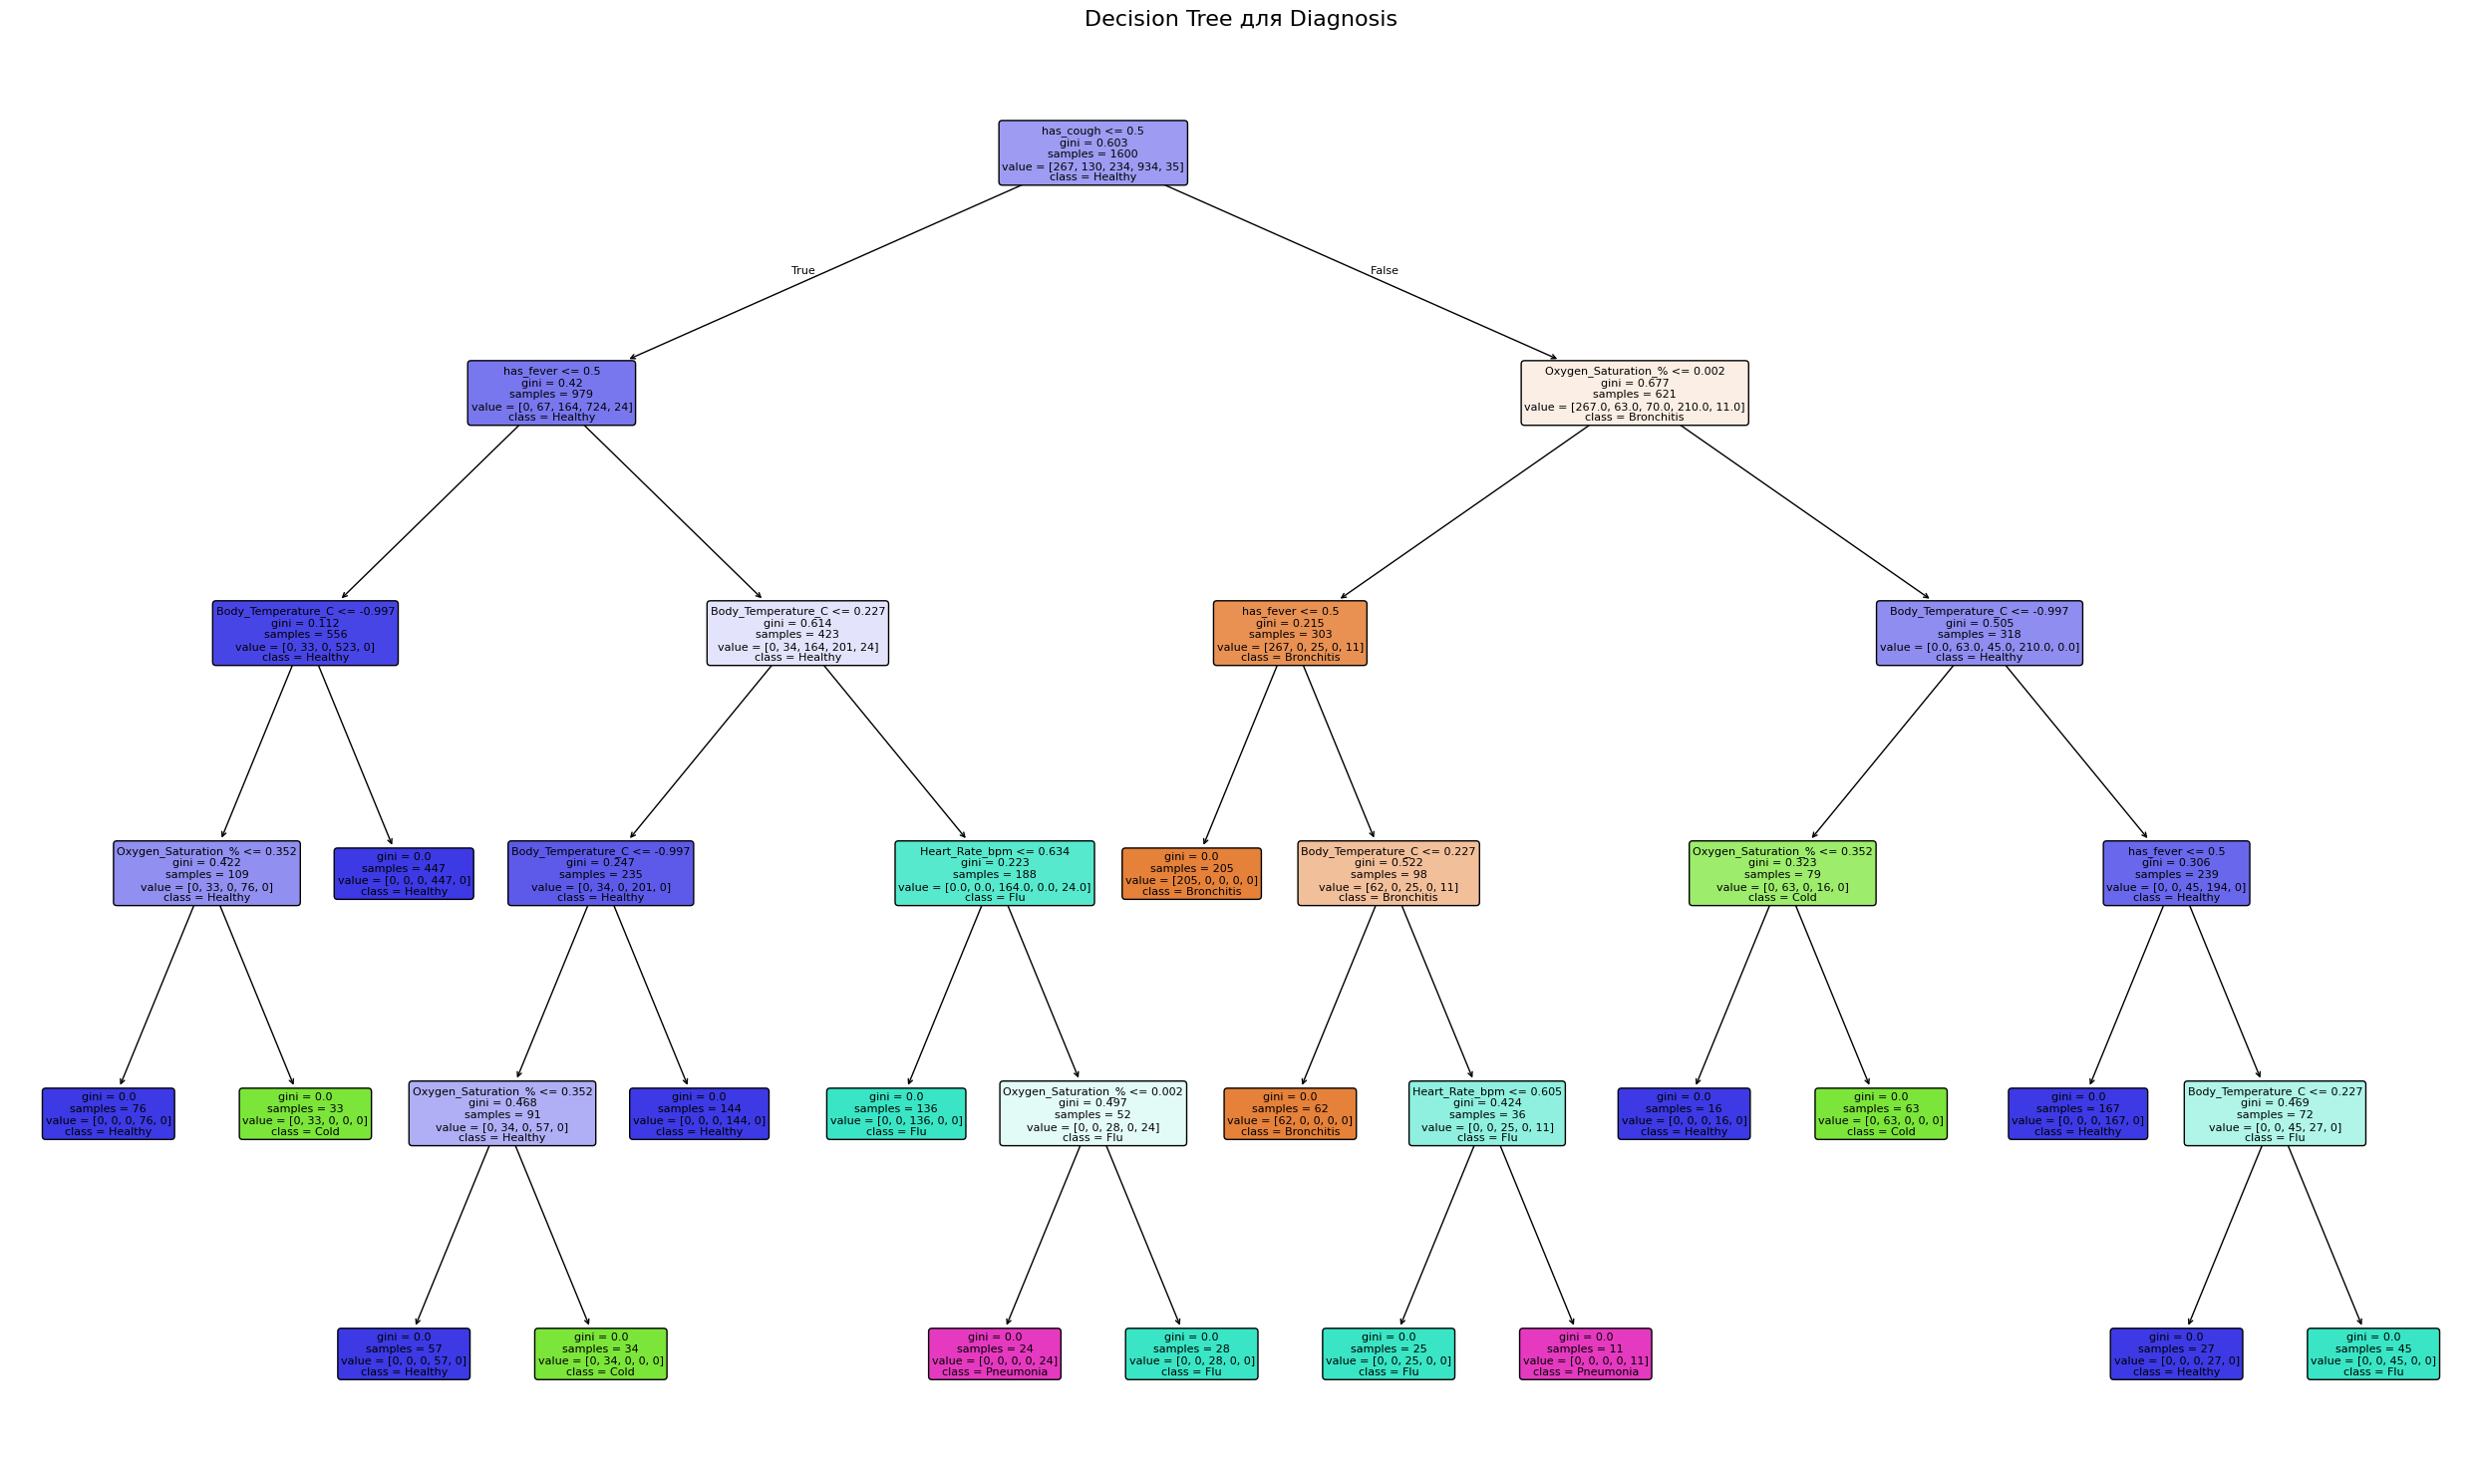



 DECISION TREE - SEVERITY


Всего признаков: 13
Глубина дерева: 5
Количество листьев: 12


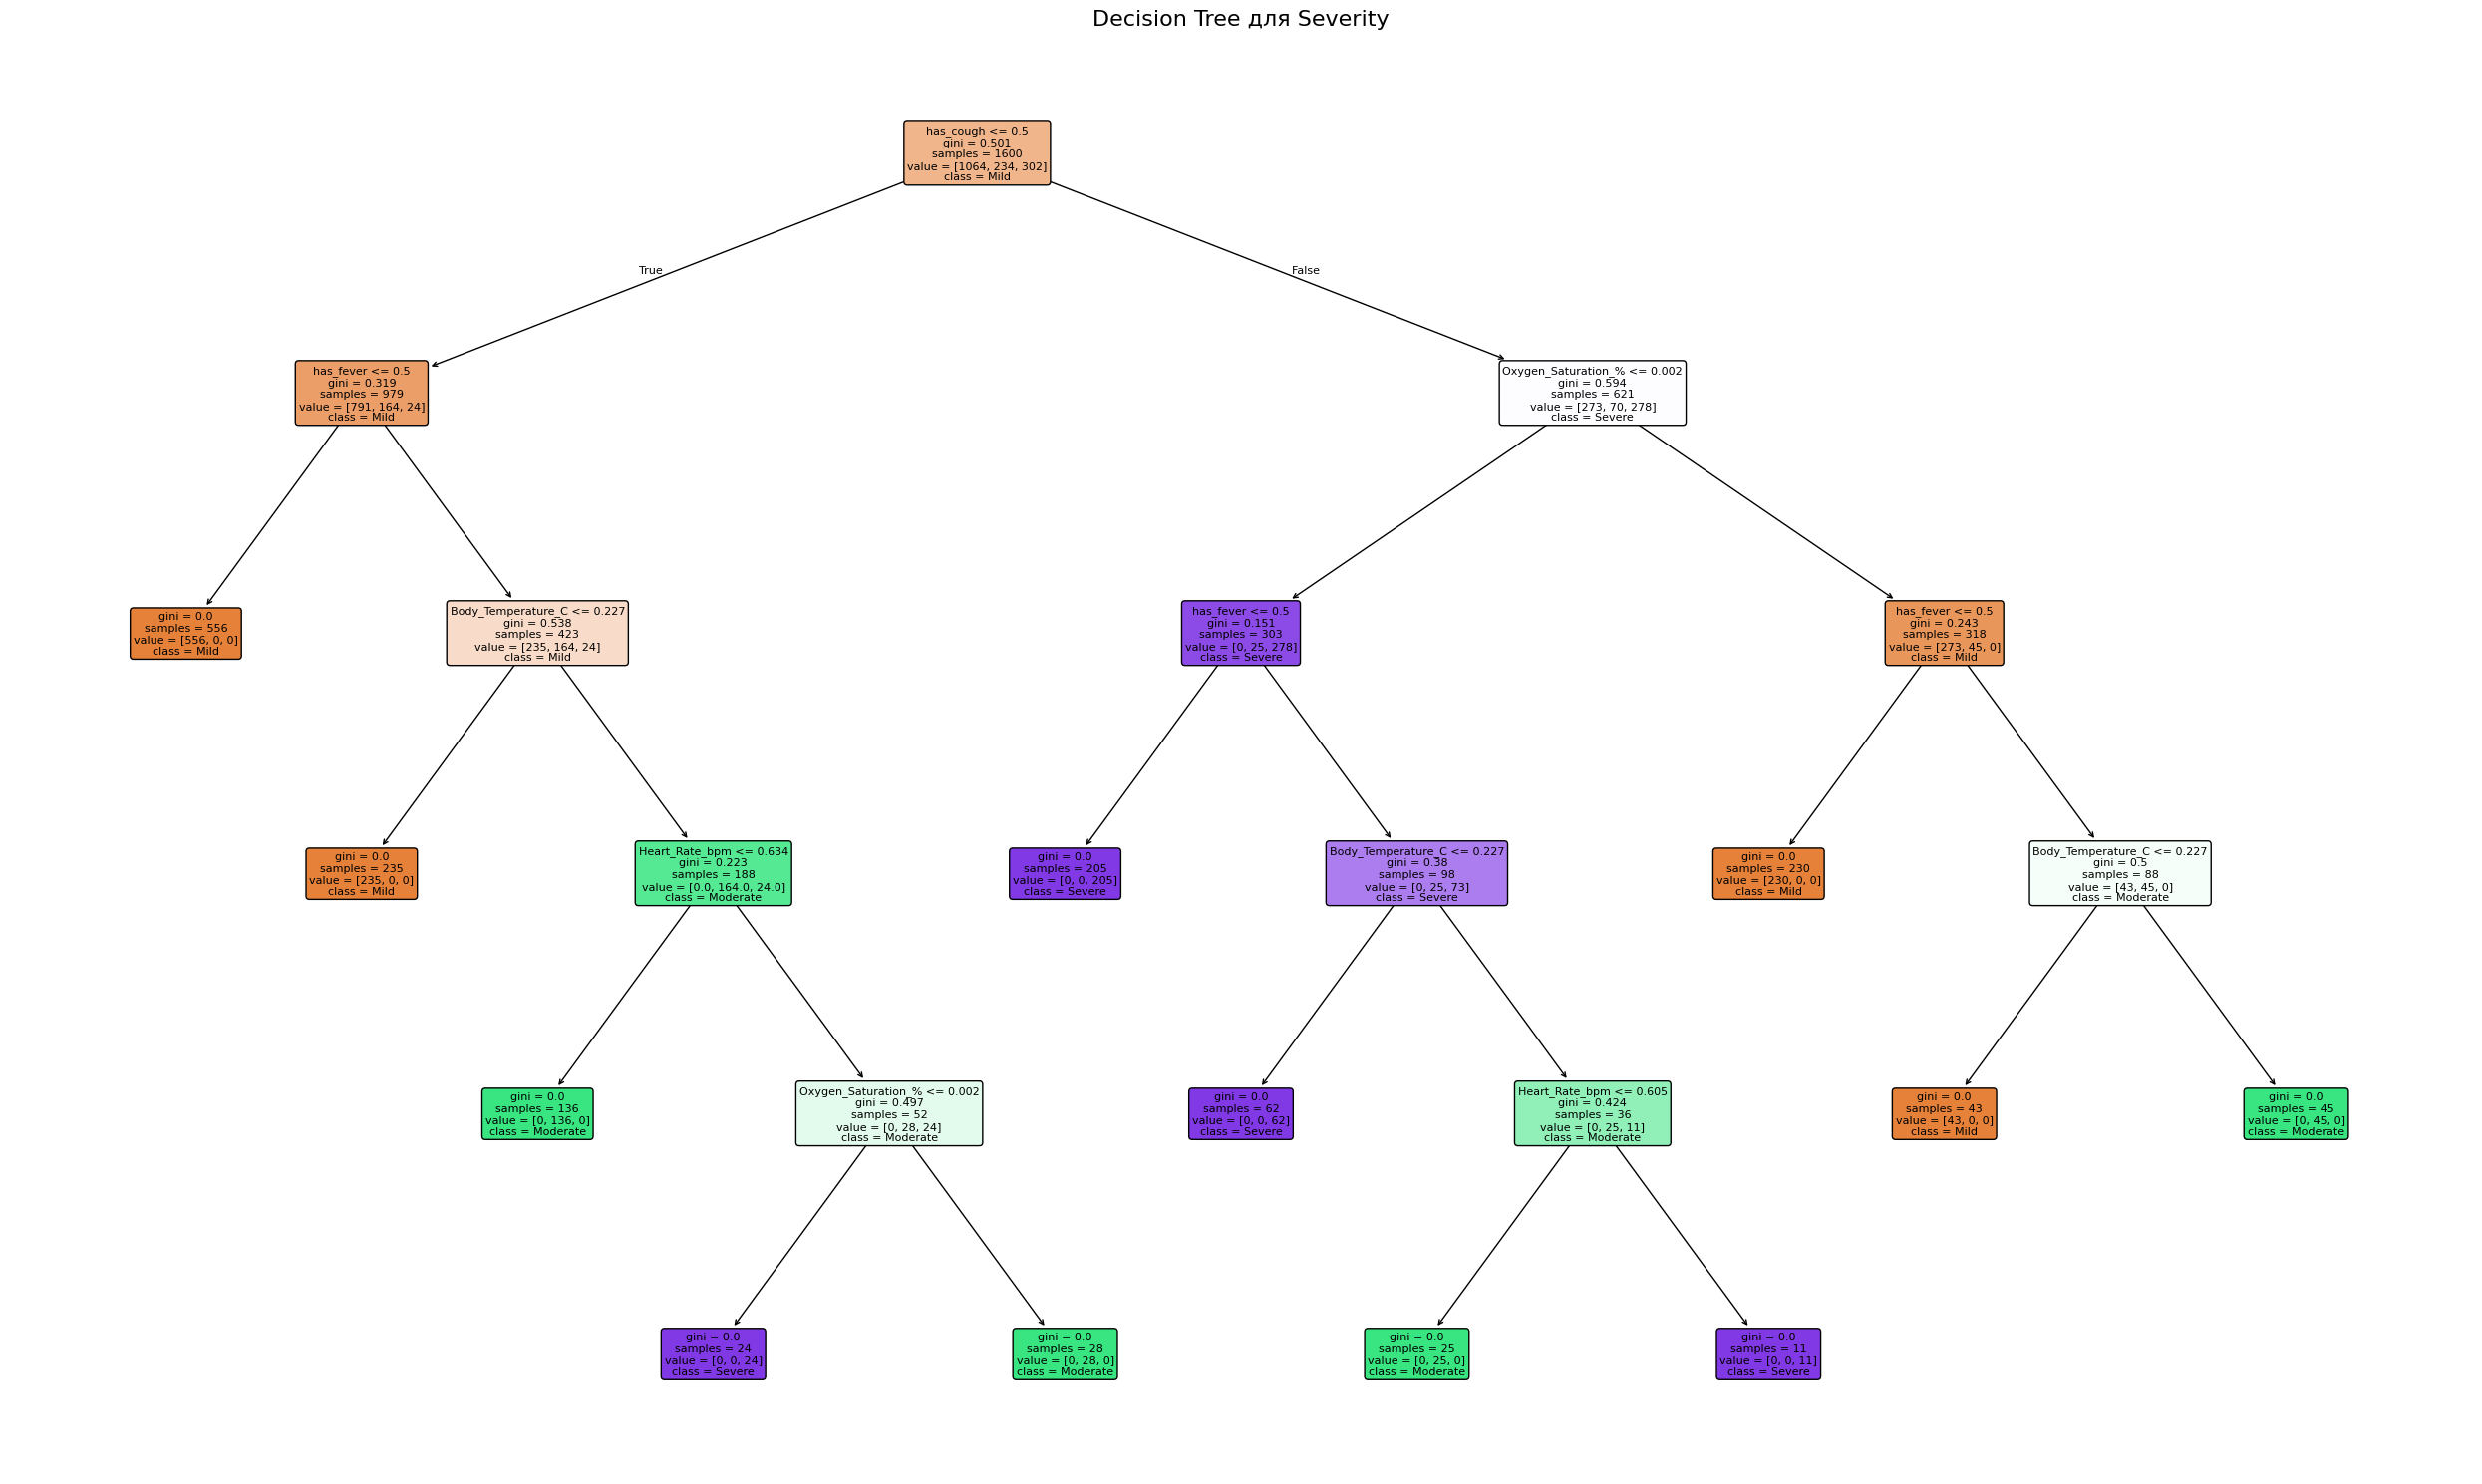



 DECISION TREE - TREATMENT_PLAN


Всего признаков: 13
Глубина дерева: 5
Количество листьев: 12


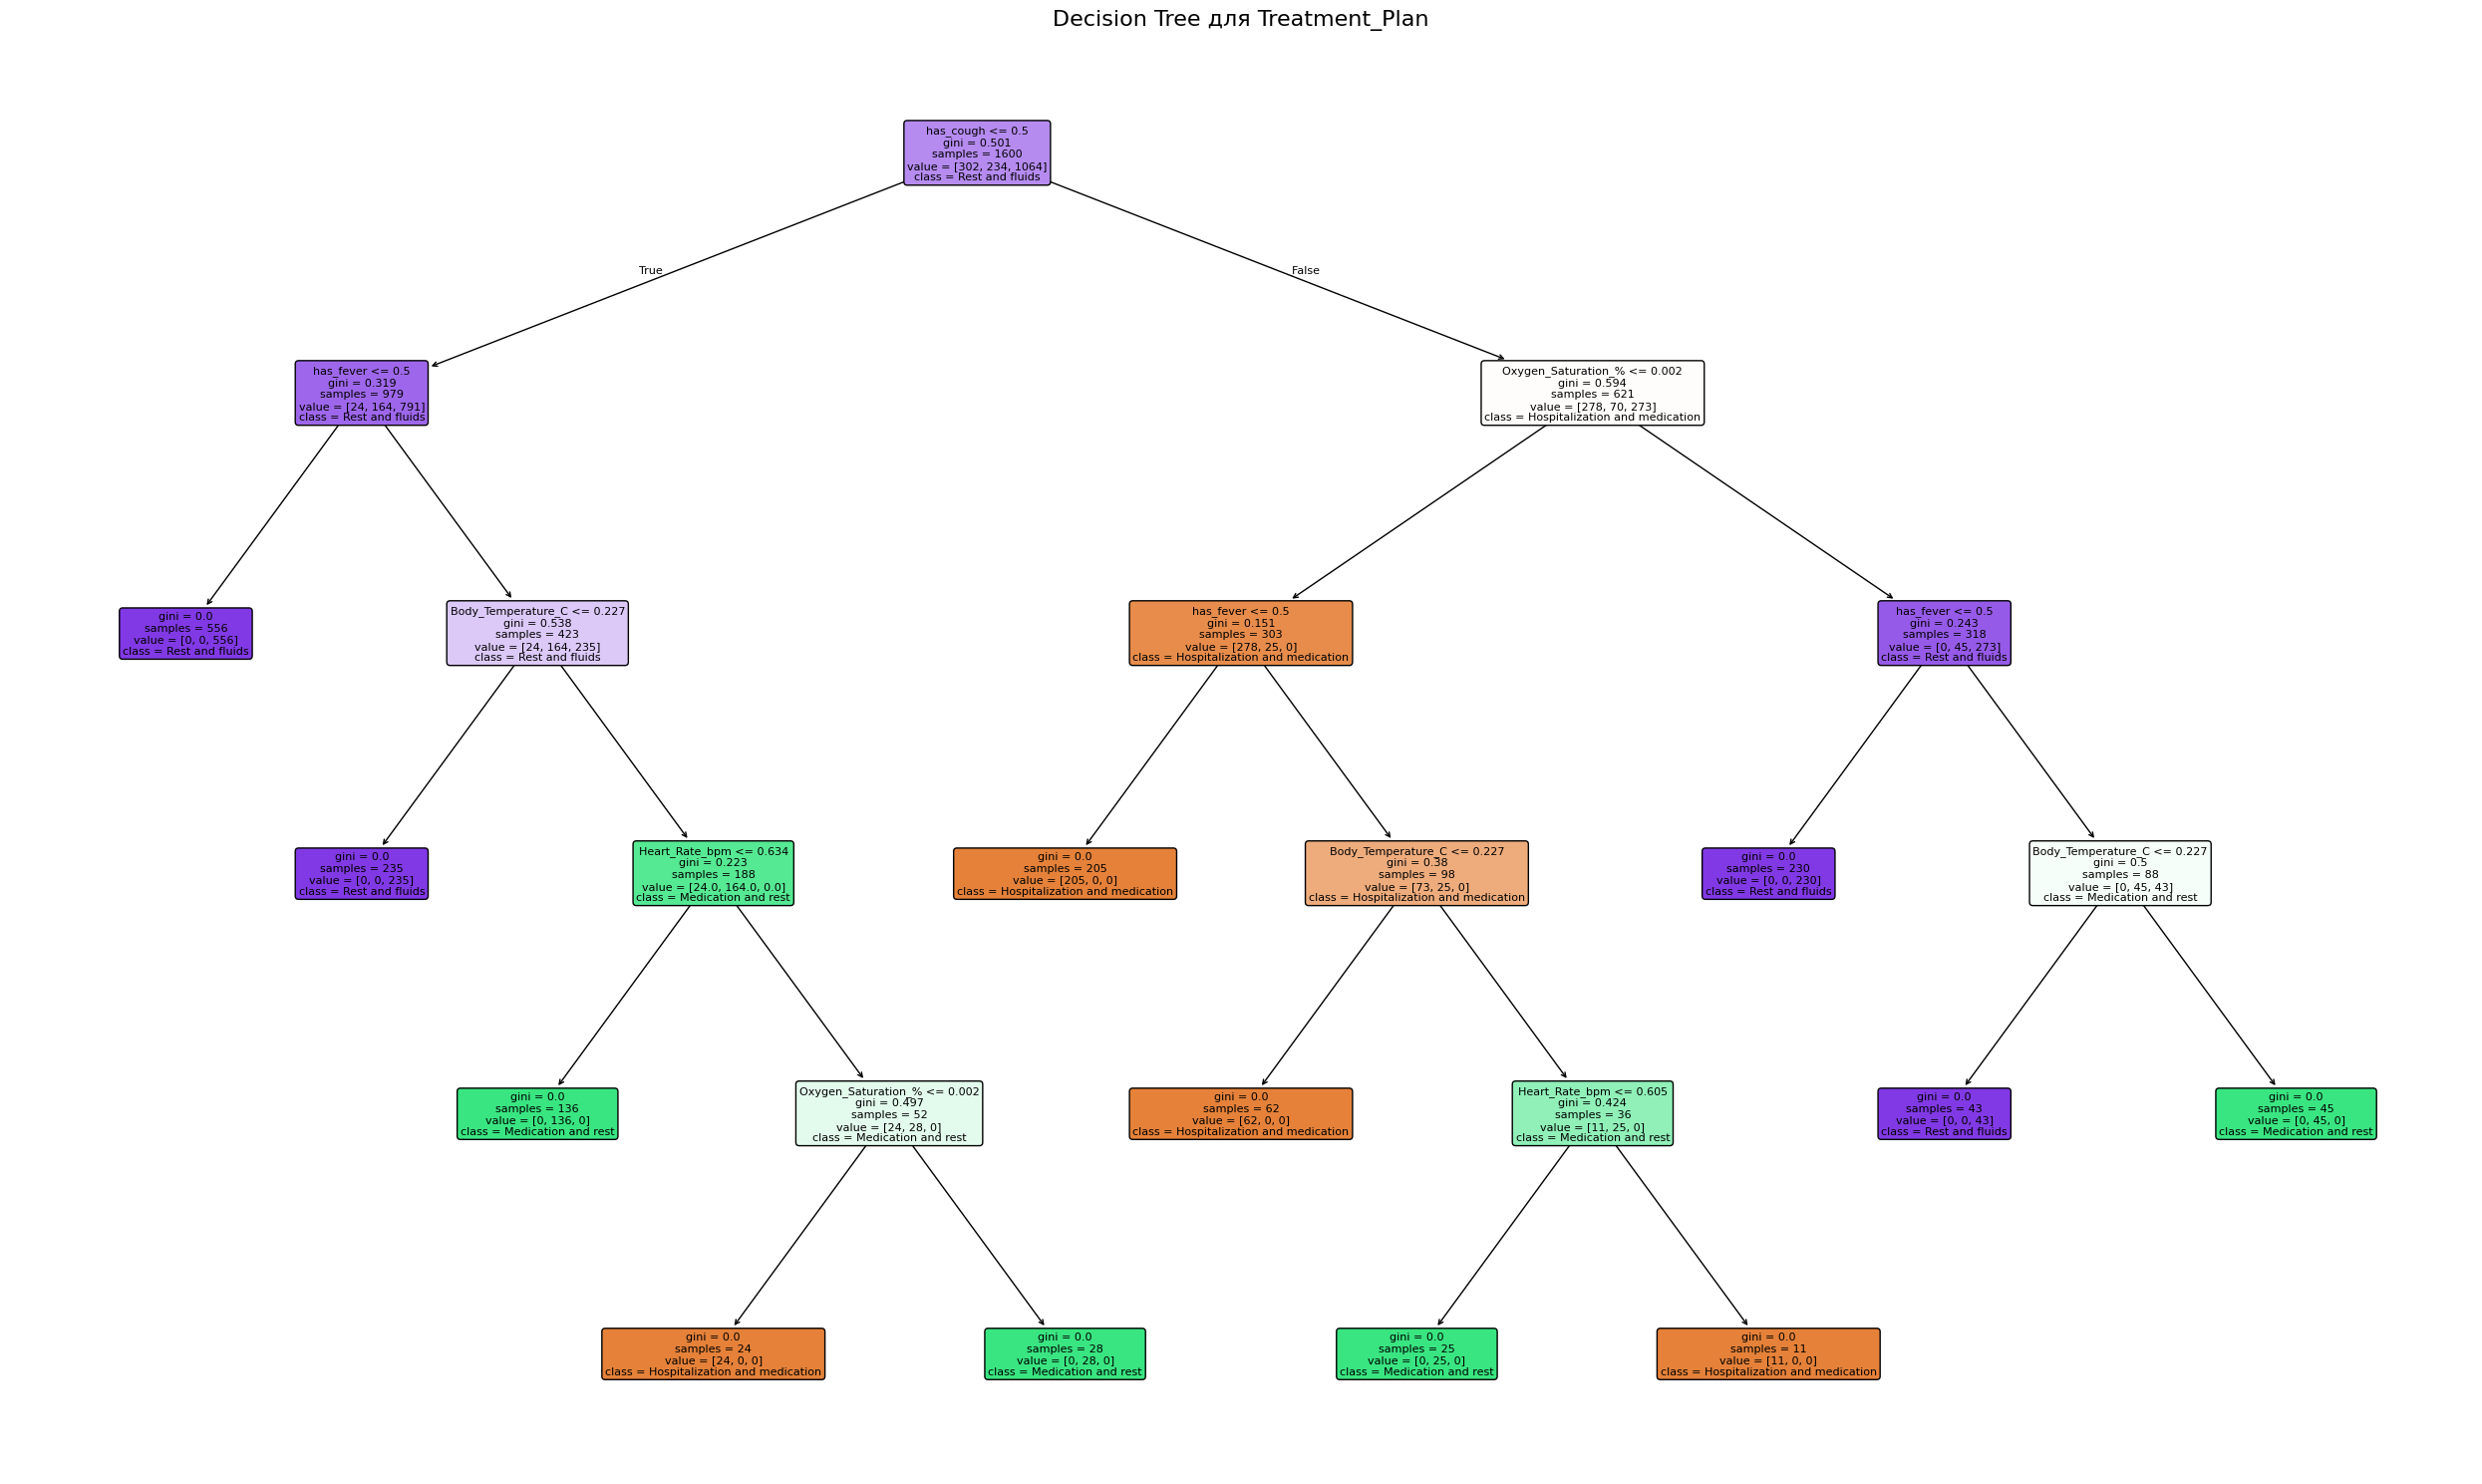

In [56]:
# Визуализация Decision Tree для всех целевых переменных
for target in target_columns:
    print(f" DECISION TREE - {target.upper()}")
    print("\n")

    dt_model = dt_models[target]

    numerical_names = numerical_features
    categorical_names = list(dt_model.named_steps['preprocessor']
                           .named_transformers_['cat']
                           .get_feature_names_out(categorical_features))
    all_feature_names = numerical_names + categorical_names + symptom_columns

    print(f"Всего признаков: {len(all_feature_names)}")
    print(f"Глубина дерева: {dt_model.named_steps['model'].get_depth()}")
    print(f"Количество листьев: {dt_model.named_steps['model'].get_n_leaves()}")

    plt.figure(figsize=(25, 15))
    plot_tree(dt_model.named_steps['model'],
              feature_names=all_feature_names,
              class_names=list(dt_model.named_steps['model'].classes_),
              filled=True,
              rounded=True,
              fontsize=8,
              max_depth=5)
    plt.title(f'Decision Tree для {target}', fontsize=16)
    plt.tight_layout()
    plt.show()
    print("\n")


Diagnosis - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3472
  2. Body_Temperature_C: 0.3348
  3. has_fever: 0.1477
  4. has_cough: 0.1379
  5. Heart_Rate_bpm: 0.0325

Severity - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3387
  2. Body_Temperature_C: 0.3140
  3. has_fever: 0.1576
  4. has_cough: 0.1507
  5. Heart_Rate_bpm: 0.0391

Treatment_Plan - Топ-5 важных признаков:
  1. Oxygen_Saturation_%: 0.3387
  2. Body_Temperature_C: 0.3140
  3. has_fever: 0.1576
  4. has_cough: 0.1507
  5. Heart_Rate_bpm: 0.0391


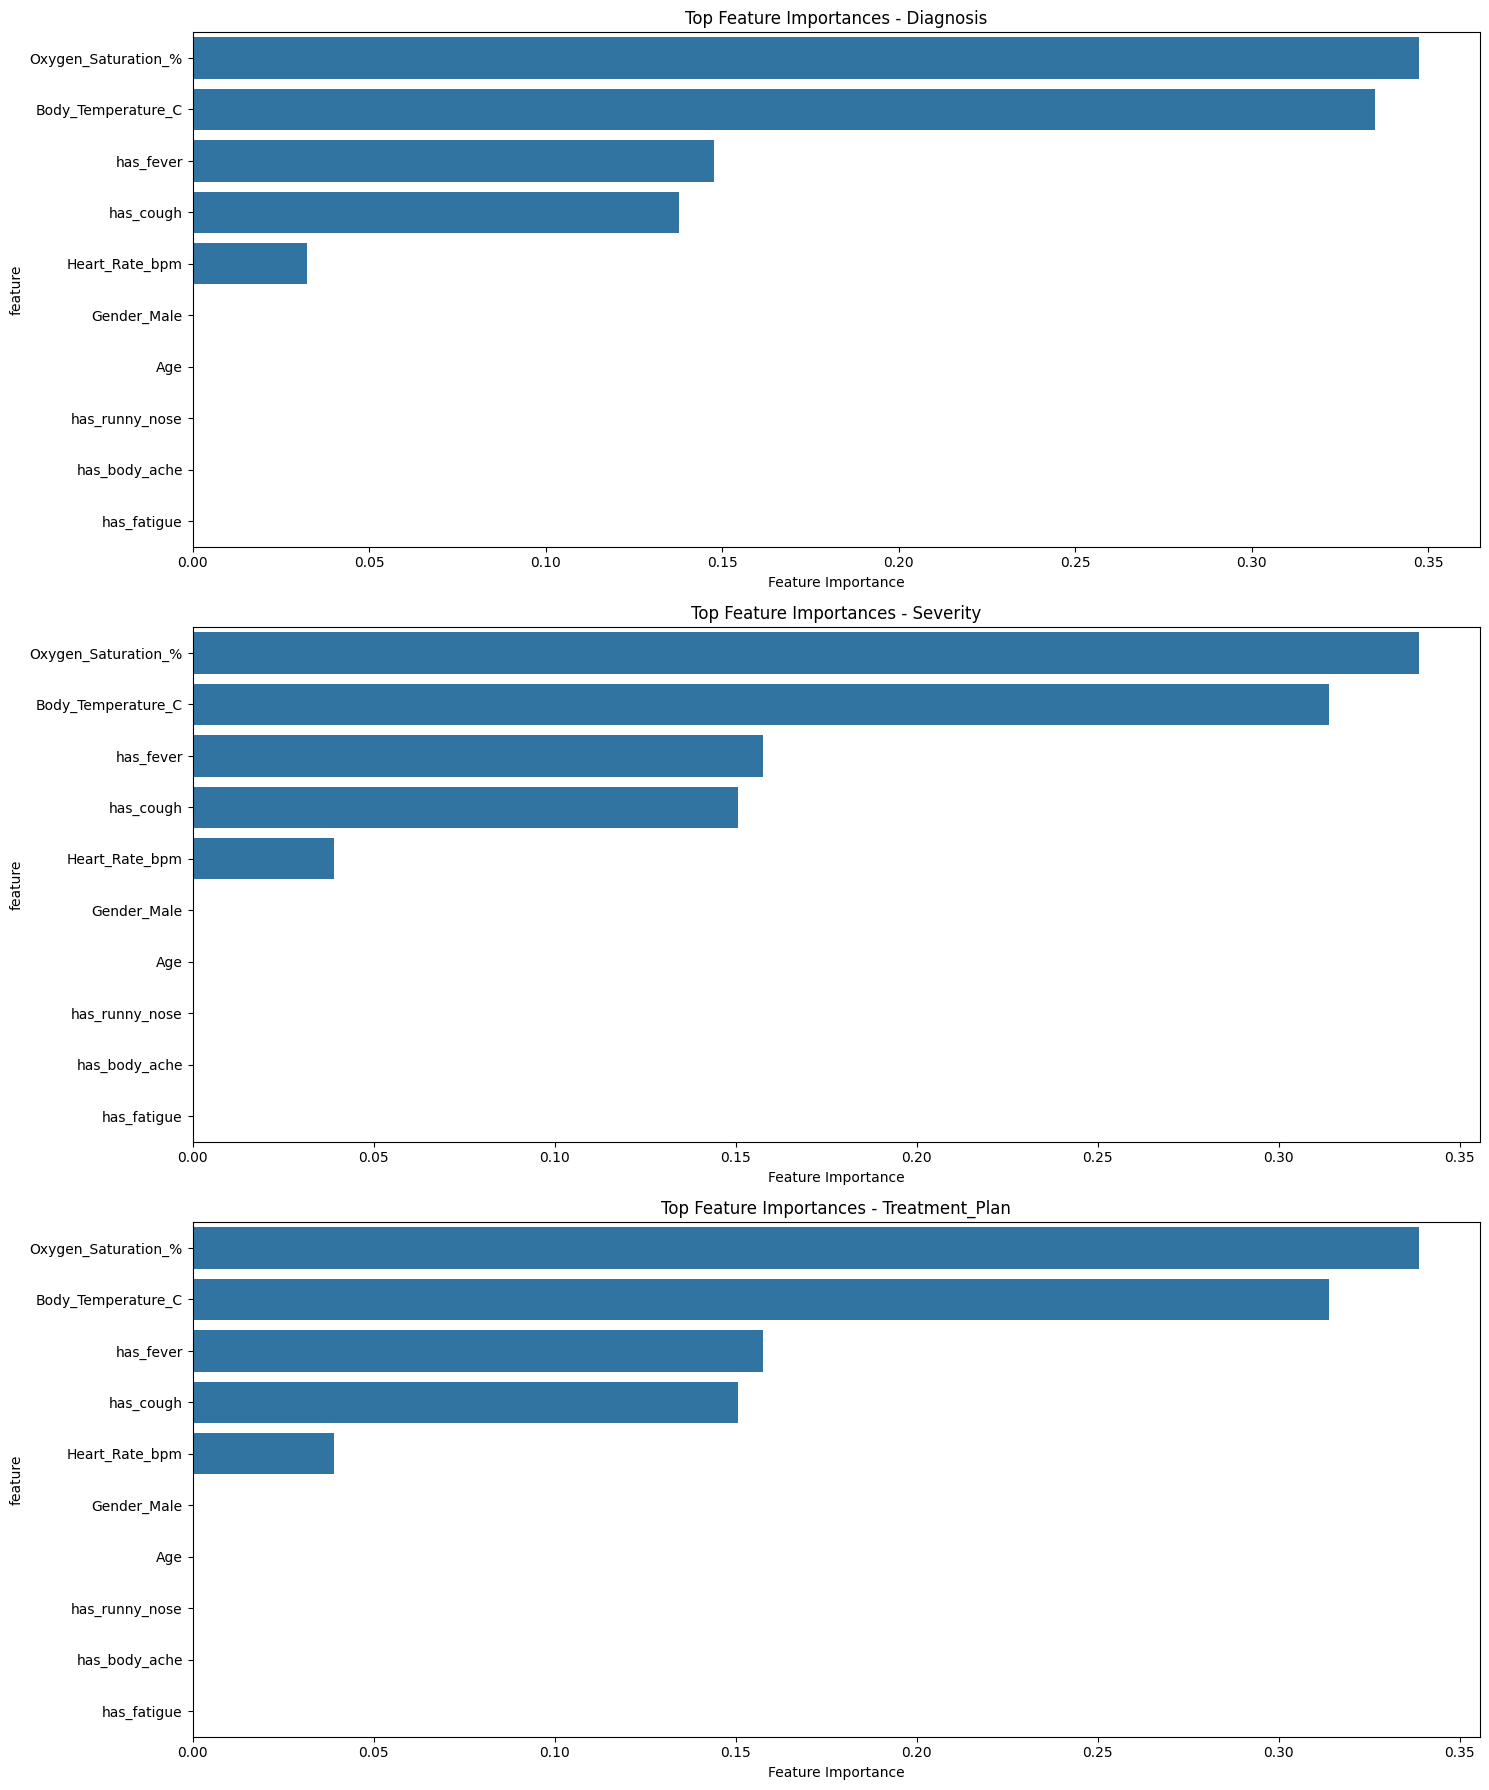

In [57]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

fig, axes = plt.subplots(3, 1, figsize=(15, 18))

for i, target in enumerate(target_columns):
    dt_model = dt_models[target]
    feature_importance = dt_model.named_steps['model'].feature_importances_

    importance_df = pd.DataFrame({
        'feature': all_feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False).head(10)

    sns.barplot(data=importance_df, x='importance', y='feature', ax=axes[i])
    axes[i].set_title(f'Top Feature Importances - {target}')
    axes[i].set_xlabel('Feature Importance')

    print(f"\n{target} - Топ-5 важных признаков:")
    for j, (_, row) in enumerate(importance_df.head(5).iterrows(), 1):
        print(f"  {j}. {row['feature']}: {row['importance']:.4f}")

plt.tight_layout()
plt.show()

In [58]:
# самыми важными оказались уровнеь кислорода, жар = температура по шкале и симптом, кашель
# логично что при поражении лёгких эти метрики сильно выбиваются относительно здоровых и легкобольных

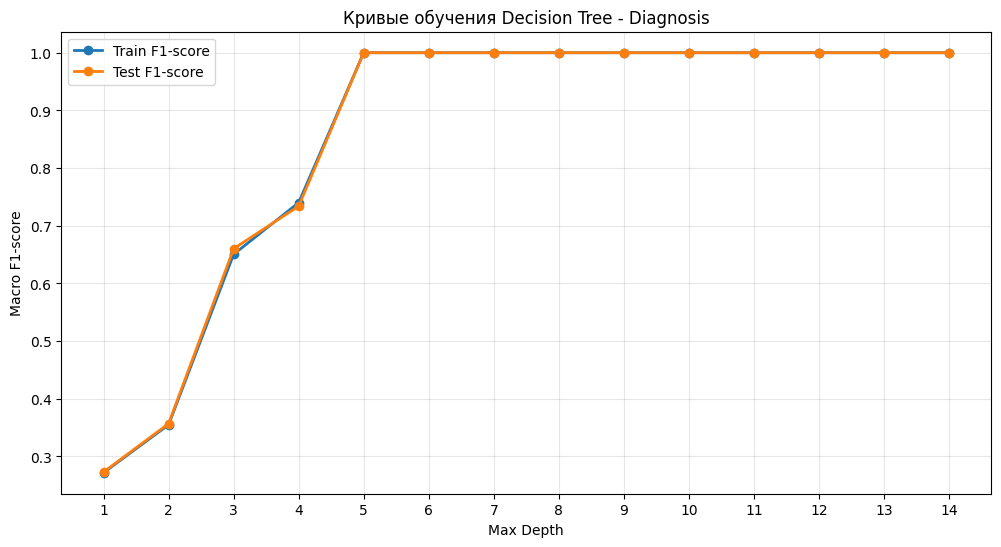

Оптимальная глубина дерева: 5
Лучший F1-score на тесте: 1.0000


In [59]:
# Анализ переобучения для Diagnosis
target_analyze = 'Diagnosis'
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    dt_depth = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE))
    ])

    dt_depth.fit(X_train, y_train[target_analyze])

    y_train_pred = dt_depth.predict(X_train)
    train_f1 = f1_score(y_train[target_analyze], y_train_pred, average='macro', zero_division=0)
    train_scores.append(train_f1)

    y_test_pred = dt_depth.predict(X_test)
    test_f1 = f1_score(y_test[target_analyze], y_test_pred, average='macro', zero_division=0)
    test_scores.append(test_f1)

plt.figure(figsize=(12, 6))
plt.plot(depths, train_scores, 'o-', label='Train F1-score', linewidth=2)
plt.plot(depths, test_scores, 'o-', label='Test F1-score', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Macro F1-score')
plt.title(f'Кривые обучения Decision Tree - {target_analyze}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.show()

optimal_depth = depths[np.argmax(test_scores)]
optimal_score = max(test_scores)
print(f"Оптимальная глубина дерева: {optimal_depth}")
print(f"Лучший F1-score на тесте: {optimal_score:.4f}")

In [60]:
# Сравнение Decision Tree с бейзлайном дами
print("Сравнение с Decision Tree")


comparison_dt = pd.DataFrame(index=target_columns)
comparison_dt['Dummy F1'] = [dummy_scores[target]['f1'] for target in target_columns]
comparison_dt['Decision Tree F1'] = [dt_scores[target]['f1'] for target in target_columns]
comparison_dt['Improvement'] = comparison_dt['Decision Tree F1'] - comparison_dt['Dummy F1']
comparison_dt['Improvement %'] = (comparison_dt['Improvement'] / comparison_dt['Dummy F1']) * 100

display(comparison_dt)

print(f"\n Средний F1-score Decision Tree: {mean_dt_f1:.4f}")
print(f"Средний F1-score бейзлайн: {mean_dummy_f1:.4f}")
print(f"Среднее улучшение: {((mean_dt_f1 - mean_dummy_f1) / mean_dummy_f1) * 100:+.2f}%")

Сравнение с Decision Tree


,Dummy F1,Decision Tree F1,Improvement,Improvement %
Diagnosis,0.147235,1.0,0.852765,579.184549
Severity,0.266266,1.0,0.733734,275.563910
Treatment_Plan,0.266266,1.0,0.733734,275.563910



 Средний F1-score Decision Tree: 1.0000
Средний F1-score бейзлайн: 0.2266
Среднее улучшение: +341.33%


In [61]:
# дерево намного лучше угадывания

 DECISION TREE мтрики



DIAGNOSIS:
--------------------------------------------------
              precision    recall  f1-score   support

  Bronchitis       1.00      1.00      1.00        67
        Cold       1.00      1.00      1.00        33
         Flu       1.00      1.00      1.00        58
     Healthy       1.00      1.00      1.00       233
   Pneumonia       1.00      1.00      1.00         9

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


Точность по классам:
  Bronchitis: 1.000
  Cold: 1.000
  Flu: 1.000
  Healthy: 1.000
  Pneumonia: 1.000

SEVERITY:
--------------------------------------------------
              precision    recall  f1-score   support

        Mild       1.00      1.00      1.00       266
    Moderate       1.00      1.00      1.00        58
      Severe       1.00      1.00      1.00        76

    accuracy                           

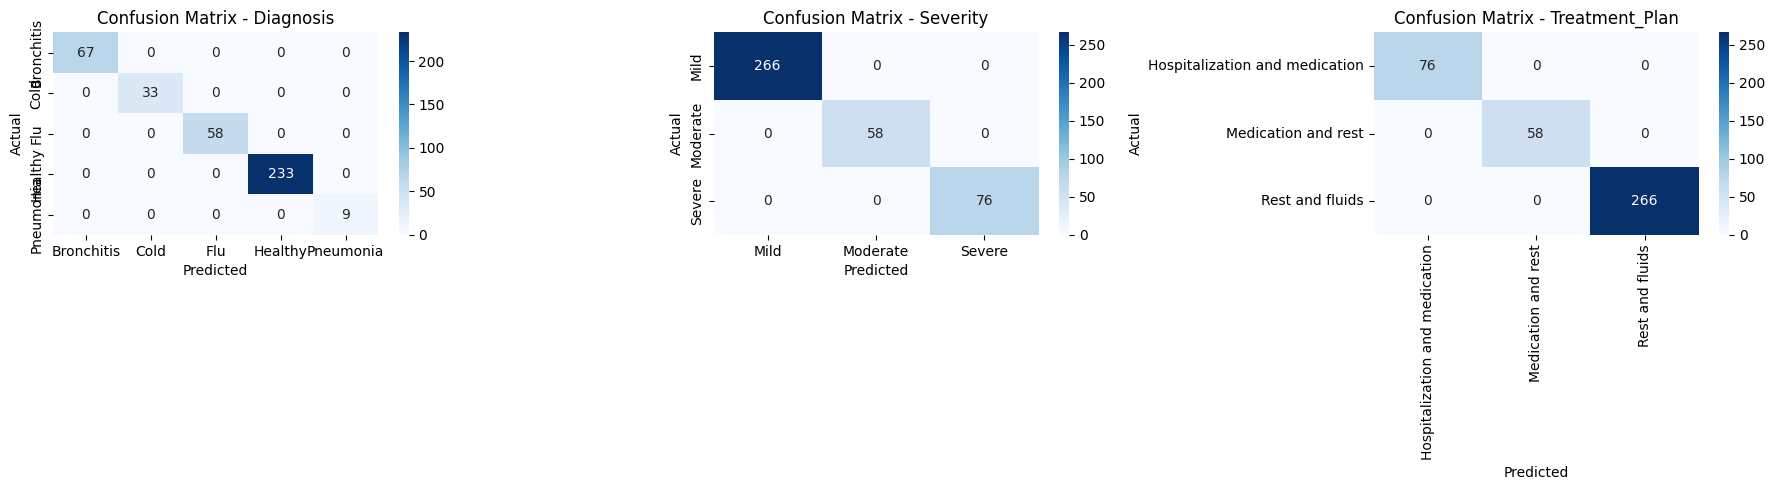

In [62]:
# метрики для Decision Tree с визуализацией матриц ошибок
print(" DECISION TREE мтрики")
print("\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, target in enumerate(target_columns):
    print(f"\n{target.upper()}:")
    print("-" * 50)

    dt_model = dt_models[target]
    y_pred = dt_model.predict(X_test)

    print(classification_report(y_test[target], y_pred, zero_division=0))

    #  матрицы ошибок
    cm = confusion_matrix(y_test[target], y_pred)
    classes = dt_model.named_steps['model'].classes_

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[i])
    axes[i].set_title(f'Confusion Matrix - {target}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

    print("\nТочность по классам:")
    for j, class_name in enumerate(classes):
        if cm[j, :].sum() > 0:
            accuracy = cm[j, j] / cm[j, :].sum()
            print(f"  {class_name}: {accuracy:.3f}")

plt.tight_layout()
plt.show()

In [63]:
# хорошие показатели

In [64]:
# Кросс-валидация
from sklearn.model_selection import cross_val_score

cv_scores = {}
for target in target_columns:
    dt_cv = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ])

    cv_f1 = cross_val_score(dt_cv, X_train, y_train[target],
                           cv=5, scoring='f1_macro', n_jobs=-1)
    cv_scores[target] = cv_f1

    print(f"\n{target} - Cross-validation F1 scores:")
    print(f"  Scores: {[f'{score:.4f}' for score in cv_f1]}")
    print(f"  Mean: {cv_f1.mean():.4f} (+/- {cv_f1.std() * 2:.4f})")

print("-" * 50)
print("\n ИТОГО:")
for target in target_columns:
    cv_mean = cv_scores[target].mean()
    test_score = dt_scores[target]['f1']
    gap = test_score - cv_mean

    print(f"{target}:")
    print(f"  CV mean: {cv_mean:.4f}")
    print(f"  Test score: {test_score:.4f}")
    print(f"  Разница: {gap:.4f}")

    if gap > 0.1:
        print(f"  Большая разница - возможное переобучение")
    elif cv_mean > 0.95:
        print(f"  Высокое качество на CV - данные хорошо разделимы")
    else:
        print(f"  Сомнительное качество")


Diagnosis - Cross-validation F1 scores:
  Scores: ['1.0000', '0.9825', '1.0000', '0.9825', '1.0000']
  Mean: 0.9930 (+/- 0.0172)

Severity - Cross-validation F1 scores:
  Scores: ['1.0000', '1.0000', '0.9937', '1.0000', '0.9937']
  Mean: 0.9975 (+/- 0.0062)

Treatment_Plan - Cross-validation F1 scores:
  Scores: ['1.0000', '1.0000', '0.9937', '1.0000', '0.9937']
  Mean: 0.9975 (+/- 0.0062)
--------------------------------------------------

 ИТОГО:
Diagnosis:
  CV mean: 0.9930
  Test score: 1.0000
  Разница: 0.0070
  Высокое качество на CV - данные хорошо разделимы
Severity:
  CV mean: 0.9975
  Test score: 1.0000
  Разница: 0.0025
  Высокое качество на CV - данные хорошо разделимы
Treatment_Plan:
  CV mean: 0.9975
  Test score: 1.0000
  Разница: 0.0025
  Высокое качество на CV - данные хорошо разделимы


In [67]:
# показатели хорошие не за счёт переобучения ,данные хорошо разделяются,модель не присваивает ложные классы